In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set()



1. Load cleaned CSVs


In [5]:

ben = pd.read_csv("../data/benin_clean.csv")
sierra = pd.read_csv("../data/sierraleone_clean.csv")
togo = pd.read_csv("../data/togo_clean.csv")


2. Add country label

In [6]:



ben['country'] = 'Benin'
sierra['country'] = 'SierraLeone'
togo['country'] = 'Togo'


3. Combine

In [7]:


df_all = pd.concat([ben, sierra, togo], ignore_index=True)


4. Convert Timestamp if necessary

In [8]:


df_all['Timestamp'] = pd.to_datetime(df_all['Timestamp'], errors='coerce')


5. Summary table per country for GHI, DNI, DHI


In [9]:

summary = df_all.groupby('country')[['GHI','DNI','DHI']].agg(['mean','median','std']).round(2)
display(summary)


GHI                    DNI                    DHI         \
               mean median     std    mean median     std    mean median   
country                                                                    
Benin        475.49  474.2  228.39  348.97  345.7  193.44  222.22  213.4   
SierraLeone  363.51  359.5  193.88  158.50  115.3  169.95  223.69  225.0   
Togo         437.07  430.3  222.00  146.06    0.0  246.06  111.73    1.0   

                     
                std  
country              
Benin        107.49  
SierraLeone   96.92  
Togo         151.04

6. Boxplots


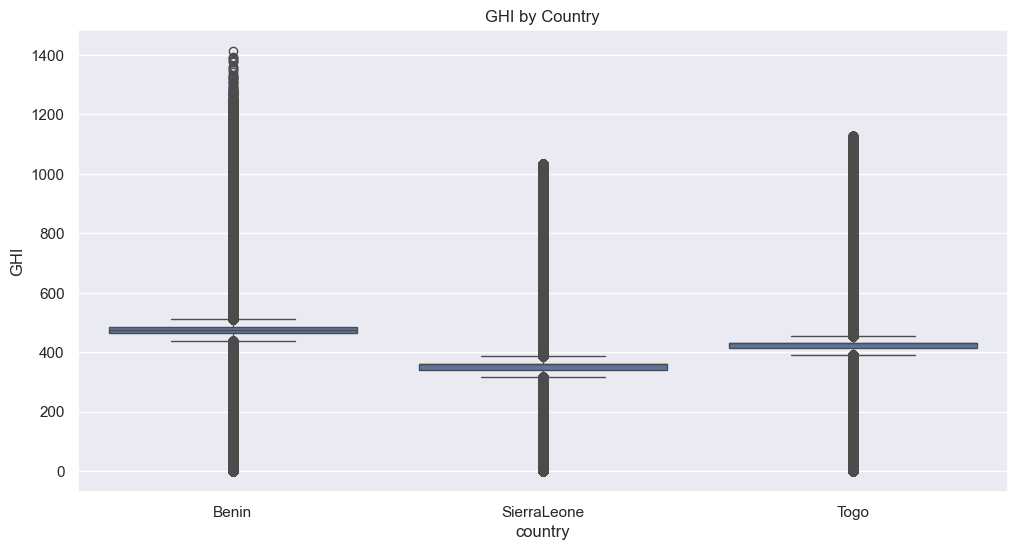

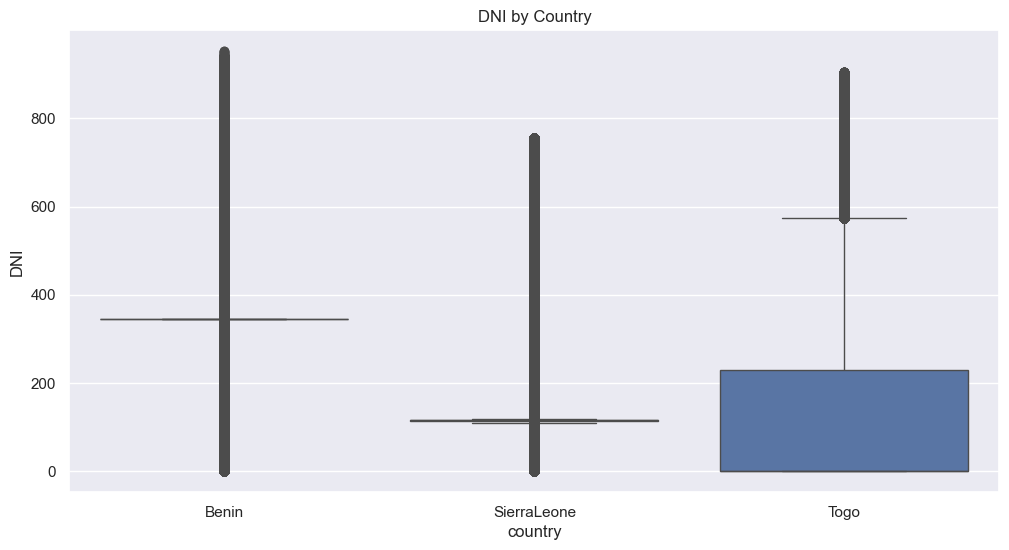

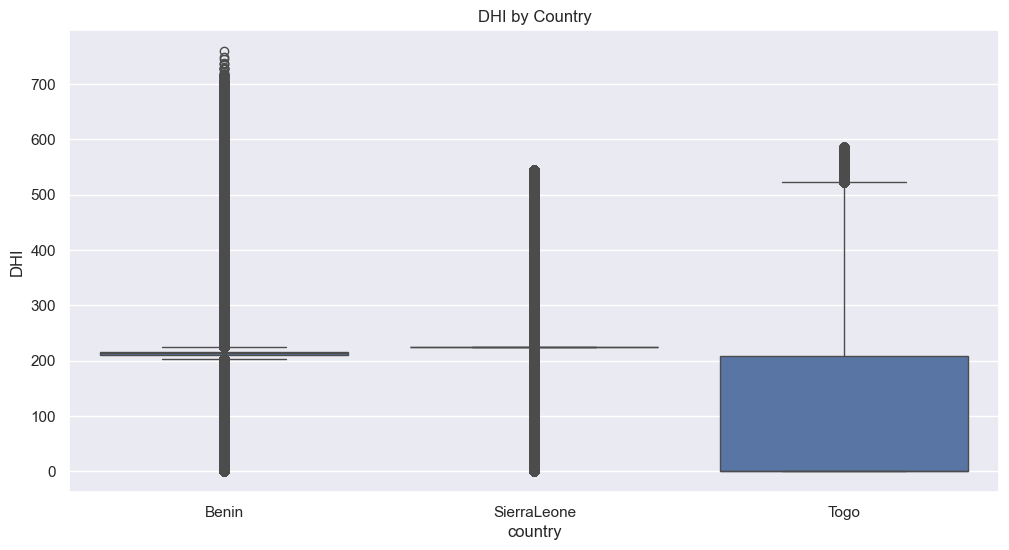

In [10]:

plt.figure(figsize=(12,6))
sns.boxplot(x='country', y='GHI', data=df_all)
plt.title("GHI by Country"); plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='country', y='DNI', data=df_all)
plt.title("DNI by Country"); plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='country', y='DHI', data=df_all)
plt.title("DHI by Country"); plt.show()


 7. (Optional) One-way ANOVA for GHI


In [11]:

ben_ghi = ben['GHI'].dropna()
sierra_ghi = sierra['GHI'].dropna()
togo_ghi = togo['GHI'].dropna()
f, p = stats.f_oneway(ben_ghi, sierra_ghi, togo_ghi)
print(f"ANOVA F={f:.3f}, p={p:.4g}")


ANOVA F=35241.296, p=0


 8. Quick observations


In [12]:

# e.g. compute means
means = df_all.groupby('country')['GHI'].mean().sort_values(ascending=False)
print("GHI means:\n", means)


GHI means:
 country
Benin          475.492396
Togo           437.066678
SierraLeone    363.512635
Name: GHI, dtype: float64
